In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
from pathlib import Path

from thefuzz import process

# Configure plot style for later visualization
sns.set_theme(style="whitegrid")
%matplotlib inline

print("Libraries loaded successfully.")

Libraries loaded successfully.


#### Data Loading

In [2]:
# --- CONFIGURATION ---
# Replace 'data' and 'carbonate_data.xlsx' with your actual folder/filename
# If the file is in the same folder as the notebook, just use Path('carbonate_data.xlsx')
FILE_PATH = Path('carb_demo_data.xlsx') 

SHEET_NAME = 'Sheet1'              # The specific tab to read (case sensitive)
COLUMN_NAME = 'Facies_Description' # The column header containing the descriptions

# --- LOADING LOGIC ---
if not FILE_PATH.exists():
    print(f"Error: The file '{FILE_PATH.resolve()}' does not exist.")
else:
    try:
        print(f"Loading data from '{FILE_PATH.name}' (Sheet: {SHEET_NAME})...")
        
        # Read Excel
        df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)

        # Clean up column names (strip whitespace) to prevent " Column" vs "Column" errors
        df.columns = df.columns.str.strip()

        # Check if the target column exists
        if COLUMN_NAME not in df.columns:
            print(f"Error: Column '{COLUMN_NAME}' not found.")
            print(f"Available columns are: {list(df.columns)}")
        else:
            # Create a clean working DataFrame
            # We drop NA values in the target column to avoid errors in the classifier
            df_clean = df[[COLUMN_NAME]].dropna().rename(columns={COLUMN_NAME: 'Original_Description'})
            
            print(f"Success! Loaded {len(df_clean)} rows.")
            display(df_clean.head())

    except Exception as e:
        print(f"An unexpected error occurred: {e}")

Loading data from 'carb_demo_data.xlsx' (Sheet: Sheet1)...
Success! Loaded 508 rows.


,Original_Description
0,Bioclastic wackestone
1,Bioclastic wackestone
2,Bioclastic wackestone
3,Bioclastic wackestone
4,Bioclastic wackestone


#### Classifier Functions

In [3]:
class CarbonateClassifier:
    def __init__(self):
        # 1. PRIMARY: Explicit Environment Keywords (Highest Priority)
        # These are the target "Standardized Facies" labels.
        self.env_rules = {
            'Basin': ['basin', 'pelagic', 'abyssal', 'globigerina'],
            'Deep Shelf': ['deep platform', 'deep shelf', 'outer ramp', 'neritic', 'marl', 'shale'],
            'Toe-of-Slope': ['toe-of-slope', 'turbidite', 'debris flow', 'breccia flow'],
            'Fore-reef Slope': ['fore-reef', 'fore-margin', 'talus', 'floatstone'],
            'Reef Core': ['core-reef', 'reef core', 'bioherm', 'biostrome', 'framestone', 'bafflestone', 'bindstone'],
            'Back-reef / Apron': ['back-reef', 'reef apron', 'rubble', 'oncoid'],
            'Patch Reef': ['patch-reef', 'patch reef'],
            'Platform Margin Shoal': ['shoal', 'margin', 'sand bar', 'bank edge', 'oolite', 'ooid', 'grainstone', 'rudstone'],
            'Open Lagoon': ['open lagoon', 'shelf lagoon', 'open platform', 'subtidal', 'wackestone', 'packstone', 'biomicrite'],
            'Restricted Lagoon': ['restricted', 'inner lagoon', 'hypersaline', 'mudstone', 'micrite', 'pelmicrite'],
            'Tidal Flat': ['tidal flat', 'intertidal', 'fenestral', 'birdseye', 'dismicrite', 'stromatolite'],
            'Sabkha / Evaporitic': ['supratidal', 'sabkha', 'anhydrite', 'gypsum', 'evaporit'],
            'Karst / Collapse': ['breccia', 'cavity', 'karst', 'collapse']
        }

        # 2. PRIORITY ORDER
        # This list ensures 'Reef' is caught before 'Lagoon' if both appear.
        # It implicitly handles the logic of Dunham/Folk by prioritizing high-energy/distinct environments.
        self.priority = [
            'Karst / Collapse', 
            'Basin', 
            'Toe-of-Slope', 
            'Fore-reef Slope', 
            'Reef Core', 
            'Patch Reef', 
            'Back-reef / Apron', 
            'Sabkha / Evaporitic', 
            'Tidal Flat', 
            'Platform Margin Shoal',  # Captures Grainstones/Sparites
            'Restricted Lagoon',      # Captures Mudstones/Micrites
            'Open Lagoon',            # Captures Wackestones/Packstones (General Subtidal)
            'Deep Shelf'
        ]

    def classify(self, text):
        """
        One-shot classification: Input Description -> Standardized Facies.
        """
        if pd.isna(text): return "Undefined"
        text_clean = str(text).lower()

        # Iterate through the priority list
        for facies in self.priority:
            keywords = self.env_rules[facies]
            # If ANY keyword for this facies is found in the text, return the label immediately
            if any(k in text_clean for k in keywords):
                return facies
        
        # Fallback
        if "dolomite" in text_clean or "dolostone" in text_clean:
            return "Diagenetic Dolomite"
            
        return "Undefined"

# Initialize
classifier = CarbonateClassifier()
print("One-Shot Classifier Ready.")

One-Shot Classifier Ready.


#### Data Processing

In [4]:
# --- THE ONE SHOT ---
df['Standardized_Environment'] = df['Facies_Description'].apply(classifier.classify)

In [5]:
df.head()

,Facies_Description,Standardized_Environment
0,Bioclastic wackestone,Open Lagoon
1,Bioclastic wackestone,Open Lagoon
2,Bioclastic wackestone,Open Lagoon
3,Bioclastic wackestone,Open Lagoon
4,Bioclastic wackestone,Open Lagoon


In [6]:
def run_environment_qaqc(df, input_col, output_col):
    """
    Generates a statistical report and visualization for the classification results.
    """
    # --- 1. STATISTICS ---
    total_rows = len(df)
    unique_facies = df[output_col].nunique()
    undefined_df = df[df[output_col] == "Undefined"]
    undefined_count = len(undefined_df)
    success_rate = ((total_rows - undefined_count) / total_rows) * 100
    
    print("="*60)
    print(f"QA/QC REPORT: {output_col}")
    print("="*60)
    print(f"Total Rows Processed:      {total_rows}")
    print(f"Unique Standardized Bins:  {unique_facies}")
    print(f"Successfully Mapped:       {total_rows - undefined_count} ({success_rate:.1f}%)")
    print(f"Unclassified / Undefined:  {undefined_count}")
    
    # --- 2. AUDIT TRAIL (Failed Items) ---
    if undefined_count > 0:
        print("-" * 60)
        print(f"WARNING: The following descriptions resulted in 'Undefined':")
        # Show top 20 unique failures to avoid flooding the screen
        failures = undefined_df[input_col].unique()[:20] 
        for f in failures:
            print(f"  [x] '{f}'")
        if len(undefined_df[input_col].unique()) > 20:
            print(f"  ... and {len(undefined_df[input_col].unique()) - 20} more.")
    else:
        print("-" * 60)
        print("SUCCESS: 100% of rows were mapped to a Standardized Facies.")

    # --- 3. VISUALIZATION ---
    plt.figure(figsize=(10, 6))
    
    # Count frequency of each facies
    order = df[output_col].value_counts().index
    
    # Create Horizontal Bar Chart
    ax = sns.countplot(
        y=output_col, 
        data=df, 
        order=order, 
        palette="viridis",
        hue=output_col,
        legend=False
    )
    
    plt.title(f"Distribution of Standardized Environment (N={total_rows})", fontsize=14)
    plt.xlabel("Sample Count", fontsize=12)
    plt.ylabel("Standardized Environment", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Add counts to the end of bars
    for container in ax.containers:
        ax.bar_label(container, padding=5)

    plt.tight_layout()
    plt.show()

QA/QC REPORT: Standardized_Environment
Total Rows Processed:      508
Unique Standardized Bins:  14
Successfully Mapped:       385 (75.8%)
Unclassified / Undefined:  123
------------------------------------------------------------
  [x] 'Winnowed edge sands'
  [x] 'Biosparite'
  [x] 'Oosparite'
  [x] 'Intrasparite'
  [x] 'Pelsparite'
  [x] 'Biolithite'
  [x] 'Dolomitized reef'
  [x] 'Fractured limestone'
  [x] 'wkstn'
  [x] 'pckstn'
  [x] 'grnstn'
  [x] 'mdst'
  [x] 'bndstn'
  [x] 'lagon'
  [x] 'dk gy mdst'
  [x] 'lt brn grnstn'
  [x] 'argillaceous lst'
  [x] 'dol'
  [x] 'skel wkstn'
  [x] 'bioclast pkstn'
  ... and 10 more.


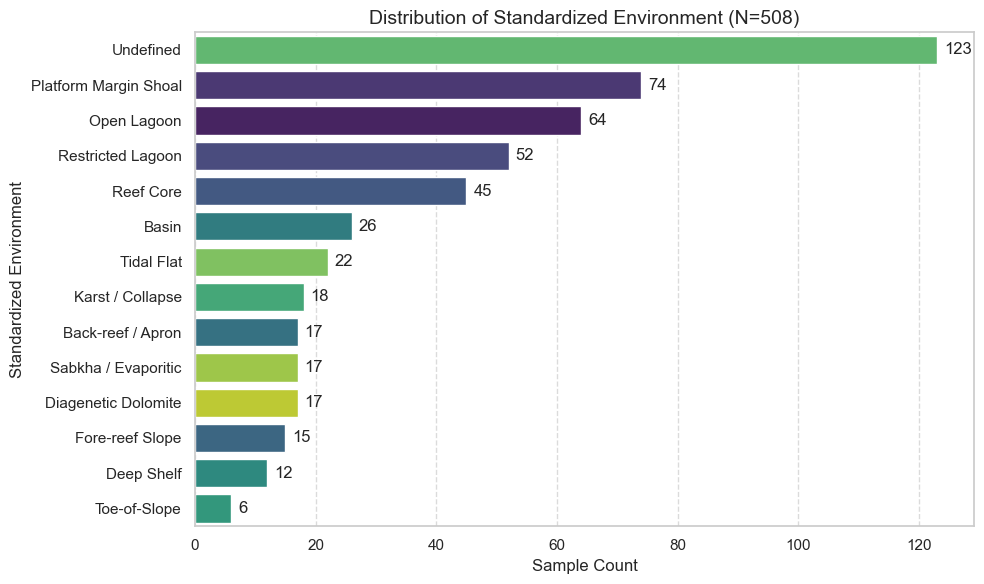

In [31]:
# --- EXECUTE ---
# Replace 'Facies_Description' and 'Standardized_Environment' with your actual column names
run_environment_qaqc(df, input_col='Facies_Description', output_col='Standardized_Environment')

#### Visualization

In [7]:
def plot_hierarchical_sankey(df, cols, title="Environment Standardization Flow", height=600, width=1200):
    """
    Generates a Sankey diagram from a Pandas DataFrame for an arbitrary list of columns.
    
    Parameters:
    - df: The dataframe containing the data
    - cols: A list of column names to link, in order (e.g., ['Sub_Environment', 'Broader_Env'])
    """
    
    # 1. Create a unique label list for Nodes
    # We add a suffix to labels to distinguish "Slope" in Col A from "Slope" in Col B
    # otherwise the lines loop back on themselves.
    labels = []
    for i, col in enumerate(cols):
        unique_vals = df[col].unique().tolist()
        # Appending the column index to ensure uniqueness (e.g., "Slope_1", "Slope_2")
        labels += [f"{val}_{i}" for val in unique_vals]
    
    # Map these unique labels to integers (0, 1, 2...) for Plotly
    label_map = {label: i for i, label in enumerate(labels)}
    
    # 2. Build Links (Source -> Target -> Value)
    sources = []
    targets = []
    values = []
    colors = []
    
    # Iterate through pairs of columns (Step 1->2, Step 2->3, etc.)
    for i in range(len(cols) - 1):
        col_source = cols[i]
        col_target = cols[i+1]
        
        # Group by the pair and count occurrences
        flow = df.groupby([col_source, col_target]).size().reset_index(name='count')
        
        for _, row in flow.iterrows():
            # Get the unique label names we created earlier
            src_label = f"{row[col_source]}_{i}"
            tgt_label = f"{row[col_target]}_{i+1}"
            
            sources.append(label_map[src_label])
            targets.append(label_map[tgt_label])
            values.append(row['count'])
            # Optional: You could assign static colors here
            
    # 3. Clean up display labels (Remove the _0, _1 suffixes for the final plot)
    display_labels = [label.rsplit('_', 1)[0] for label in labels]

    # 4. Create the Plot
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=display_labels,
            color="blue"
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            # color="rgba(200, 200, 200, 0.5)" # clear grey links
        )
    )])

    fig.update_layout(title_text=title, font_size=12, height=height, width=width)
    fig.show()

print("Sankey Generator Function ready.")

Sankey Generator Function ready.


In [8]:
# --- DIAGRAM 1: The Main Aggregation Branch ---
# Flow: Description -> 
print("Interactive Diagram: Physical Aggregation Branch")
plot_hierarchical_sankey(
    df, 
    cols=['Facies_Description', 'Standardized_Environment'], 
    title="Carbonate Facie to Environment Aggregation Logic",
    height=1800
)

Interactive Diagram: Physical Aggregation Branch


#### Clean Data Export

In [23]:
# --- SAVE RESULTS ---
OUTPUT_SHEET = 'Normalized_Environments' 
try:
    with pd.ExcelWriter(FILE_PATH, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        df.to_excel(writer, sheet_name=OUTPUT_SHEET, index=False)
    print(f"Success: Processed data saved to sheet '{OUTPUT_SHEET}'")
except Exception as e:
    print(f"Save Failed: {e}")

Success: Processed data saved to sheet 'Normalized_Environments'


In [ ]:
# Alternate Save to CSV
output_filename = 'standardized_facies_folk_dunham.csv'
df.to_csv(output_filename, index=False)
print(f"Success! Data saved to {output_filename}")